In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from HelperFunctions import *

- Import Dataset
- Convert Attribute Values

In [29]:
df = pd.read_csv('Quality of Service 5G.csv')
df

,Timestamp,User_ID,Application_Type,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
0,9/3/2023 10:00,User_1,Video_Call,-75 dBm,30 ms,10 Mbps,15 Mbps,70%
1,9/3/2023 10:00,User_2,Voice_Call,-80 dBm,20 ms,100 Kbps,120 Kbps,80%
2,9/3/2023 10:00,User_3,Streaming,-85 dBm,40 ms,5 Mbps,6 Mbps,75%
3,9/3/2023 10:00,User_4,Emergency_Service,-70 dBm,10 ms,1 Mbps,1.5 Mbps,90%
4,9/3/2023 10:00,User_5,Online_Gaming,-78 dBm,25 ms,2 Mbps,3 Mbps,85%
...,...,...,...,...,...,...,...,...
395,9/3/2023 10:06,User_396,Streaming,-110 dBm,61 ms,1.3 Mbps,1.8 Mbps,85%
396,9/3/2023 10:06,User_397,Video_Call,-40 dBm,53 ms,14.5 Mbps,15.8 Mbps,75%
397,9/3/2023 10:06,User_398,Video_Streaming,-113 dBm,58 ms,1.0 Mbps,1.4 Mbps,70%
398,9/3/2023 10:06,User_399,Emergency_Service,-40 dBm,5 ms,0.4 Mbps,0.4 Mbps,70%


In [30]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Resource_Allocation'] = df['Resource_Allocation'].str.replace('%','').astype('int')
df['Latency'] = df['Latency'].str.replace('ms','').astype('float')
df['Signal_Strength'] = df['Signal_Strength'].str.replace(' dBm','').astype('int')

In [31]:
df['Required_Bandwidth'] = df['Required_Bandwidth'].map(mbps_to_kbps)
df['Allocated_Bandwidth'] = df['Allocated_Bandwidth'].map(mbps_to_kbps)
df['Required_Bandwidth'] = df['Required_Bandwidth'].str.replace(' Kbps','').astype('float')
df['Allocated_Bandwidth'] = df['Allocated_Bandwidth'].str.replace(' Kbps','').astype('float')
unique_count = df['Application_Type'].nunique()
print("Number of unique application types:", unique_count)
df

Number of unique application types: 11


,Timestamp,User_ID,Application_Type,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
0,2023-09-03 10:00:00,User_1,Video_Call,-75,30.0,10000.0,15000.0,70
1,2023-09-03 10:00:00,User_2,Voice_Call,-80,20.0,100.0,120.0,80
2,2023-09-03 10:00:00,User_3,Streaming,-85,40.0,5000.0,6000.0,75
3,2023-09-03 10:00:00,User_4,Emergency_Service,-70,10.0,1000.0,1500.0,90
4,2023-09-03 10:00:00,User_5,Online_Gaming,-78,25.0,2000.0,3000.0,85
...,...,...,...,...,...,...,...,...
395,2023-09-03 10:06:00,User_396,Streaming,-110,61.0,1300.0,1800.0,85
396,2023-09-03 10:06:00,User_397,Video_Call,-40,53.0,14500.0,15800.0,75
397,2023-09-03 10:06:00,User_398,Video_Streaming,-113,58.0,1000.0,1400.0,70
398,2023-09-03 10:06:00,User_399,Emergency_Service,-40,5.0,400.0,400.0,70


- Heatmap for numeric columns

Positive values in heatmap: Positive correlation (increase var1 => increase var2)

Negative values in heatmap: Negative correlation (increase var1 => decrease var2)

Zero values in heatmap: No correlation

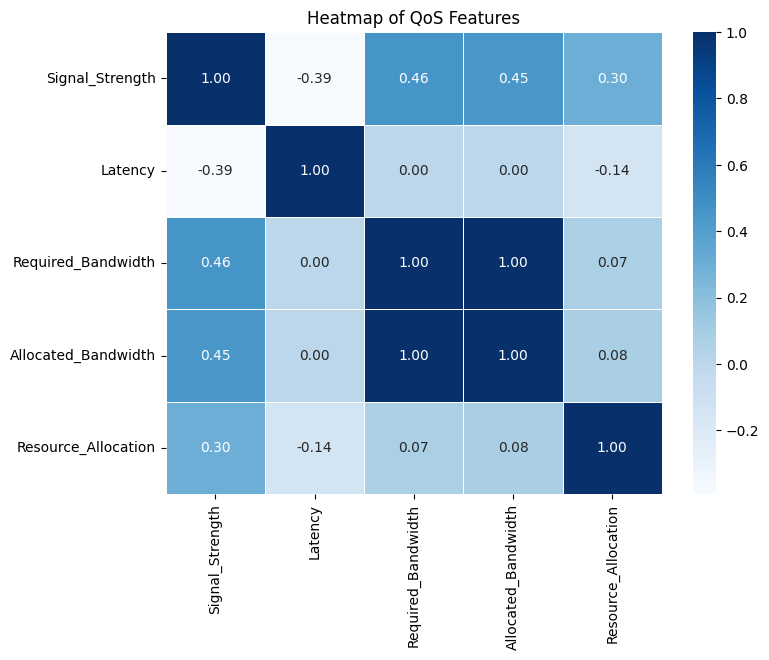

In [32]:
numeric_vars = ["Signal_Strength", "Latency", "Required_Bandwidth", "Allocated_Bandwidth", "Resource_Allocation"]

df_numeric = df[numeric_vars]
correlation_matrix = df_numeric.corr()

plot_heatmap(correlation_matrix)

- Z-score for numeric columns

Scaler returns numpy array, we convert it back to data frame

In [33]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)
df_scaled = pd.DataFrame(df_scaled, columns=df_numeric.columns)

df_scaled

,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
0,0.265777,-0.181316,1.725130,2.580707,-0.525300
1,0.023942,-0.655346,-0.762862,-0.759195,0.589396
2,-0.217894,0.292713,0.468569,0.560605,0.032048
3,0.507612,-1.129376,-0.536680,-0.449446,1.704091
4,0.120676,-0.418331,-0.285368,-0.112762,1.146743
...,...,...,...,...,...
395,-1.427070,1.288176,-0.461287,-0.382109,1.146743
396,1.958624,0.908952,2.856035,2.760271,0.032048
397,-1.572171,1.145967,-0.536680,-0.471891,-0.525300
398,1.958624,-1.366391,-0.687468,-0.696347,-0.525300


- Elbow Method For K-means Algorithm

The optimal number of clusters Elbow Method: 5


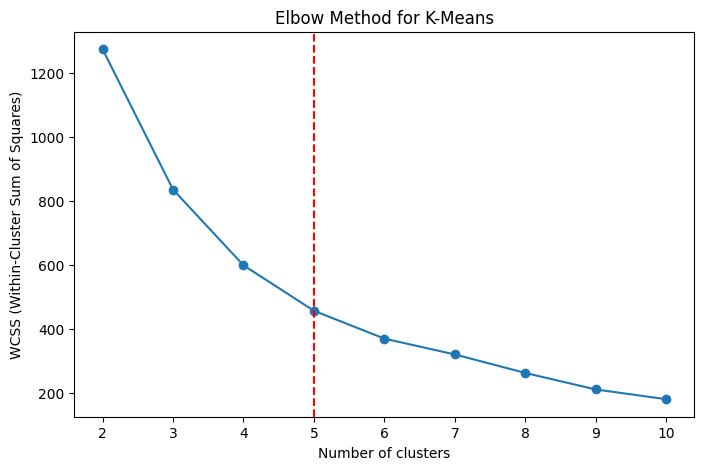

Optimal number of clusters C-Index: 10
Optimal number of clusters Silhouette Score: 9


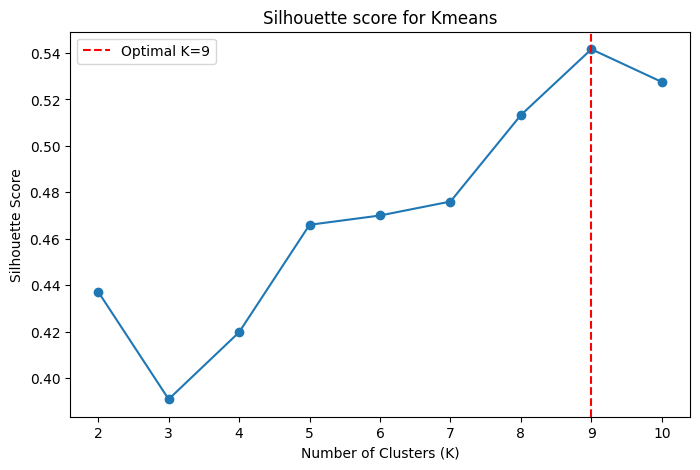

In [34]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

wcss = []  # Within-cluster sum of squares
c_index_kmeans = [] #C-index of each cluster iteration
silhouette_scores = []
data = df_scaled.values  # Convert to numpy array
K_range = range(2,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # kmeans.fit(df_scaled)
    labels_kmeans = kmeans.fit_predict(data)
    wcss.append(kmeans.inertia_)
    c_index_kmeans.append(compute_c_index(data, labels_kmeans))
    silhouette_scores.append(silhouette_score(df_scaled, labels_kmeans))

'''
Elbow Point
'''
# Use Knee Locator to find Elbow Point
kneedle = KneeLocator(list(K_range), wcss, curve="convex", direction="decreasing")
elbow_k = kneedle.elbow
print(f"The optimal number of clusters Elbow Method: {elbow_k}")
plot_elbow_kmeans(elbow_k,K_range,wcss)

'''
C-index
'''
cindex_k = list(K_range)[np.argmin(c_index_kmeans)]
print(f"Optimal number of clusters C-Index: {cindex_k}")

'''
Highest Silhouette Score
'''
silhouette_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters Silhouette Score: {silhouette_k}")
plot_silhouette_scores(silhouette_k,K_range,silhouette_scores,"Silhouette score for Kmeans")


- Compare optimal results

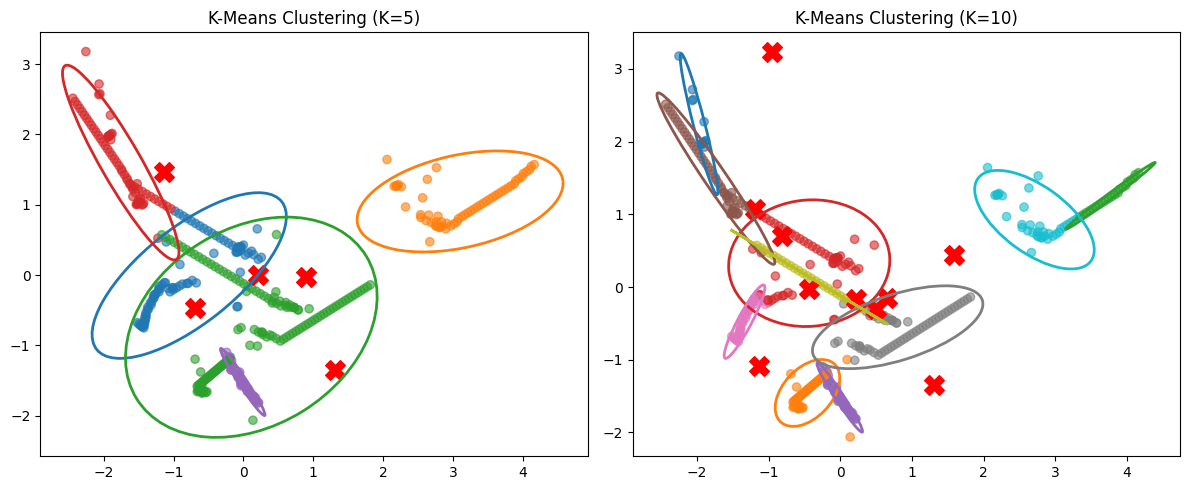

In [35]:
kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_5 = kmeans_5.fit_predict(df_scaled)

kmeans_10 = KMeans(n_clusters=10, random_state=42, n_init=10)
labels_10 = kmeans_10.fit_predict(df_scaled)

from sklearn.decomposition import PCA

# Reduce data to 2D
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled.values) 

plt.figure(figsize=(12, 5))

# Scatter plot for K=5
unique_labels_5 = np.unique(labels_5)
cmap = plt.get_cmap('tab10')
color_map_5 = {label: cmap(i % 10) for i, label in enumerate(unique_labels_5)}

ax1 = plt.subplot(1, 2, 1)
colors_for_scatter = [color_map_5[label] for label in labels_5]
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=colors_for_scatter, alpha=0.6)
plt.scatter(kmeans_5.cluster_centers_[:, 0], kmeans_5.cluster_centers_[:, 1], marker='X', s=200, c='red')
plot_confidence_ellipses(ax1, df_pca, labels_5, color_map_5)
plt.title("K-Means Clustering (K=5)")

# Scatter plot for K=10

unique_labels_10 = np.unique(labels_10)
cmap = plt.get_cmap('tab10')
color_map_10 = {label: cmap(i % 10) for i, label in enumerate(unique_labels_10)}

ax2 = plt.subplot(1, 2, 2)
colors_for_scatter = [color_map_10[label] for label in labels_10]
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=colors_for_scatter, alpha=0.6)
plt.scatter(kmeans_10.cluster_centers_[:, 0], kmeans_10.cluster_centers_[:, 1], marker='X', s=200, c='red')
plot_confidence_ellipses(ax2, df_pca, labels_10, color_map_10)
plt.title("K-Means Clustering (K=10)")

plt.tight_layout()
plt.show()

- Run K-means Algorithm for optimal number of clusters based on PCA results

In [36]:
# Optimal number of clusters for K-means based on PCA is 
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df_scaled)

- Ward Linkage Method

Ward linkage is a method used in hierarchical clustering to determine the distance between two clusters before merging them.
The goal of Ward linkage is to minimize the increase in variance within the newly formed cluster when two clusters are combined.

https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html

- Dendogram for agglomerative with Ward Method

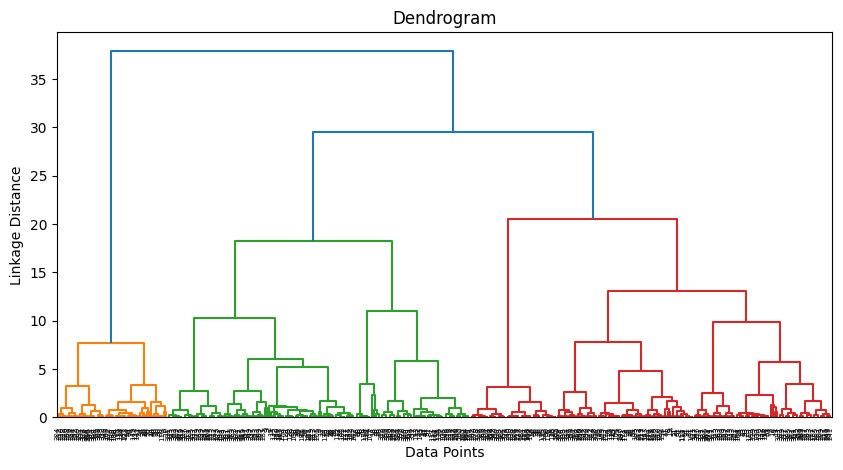

In [37]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# Compute the Ward linkage matrix
linkage_matrix = sch.linkage(df_scaled, method='ward')

plot_dendogram(linkage_matrix)

- Find Elbow Optimal K 

The optimal number of clusters is: 3


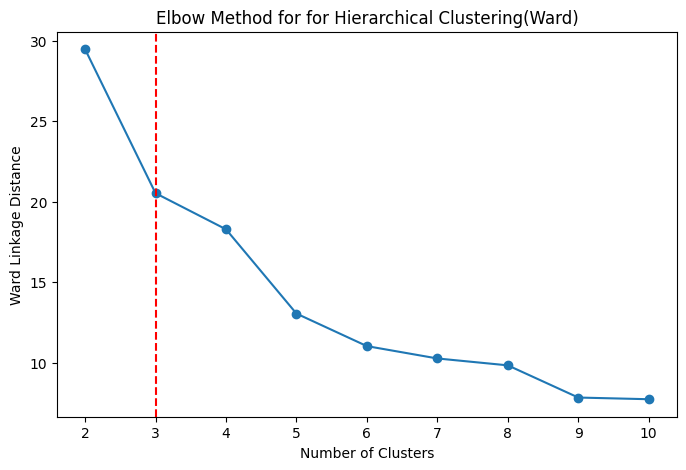

Optimal number of clusters from Silhouette Score: 9


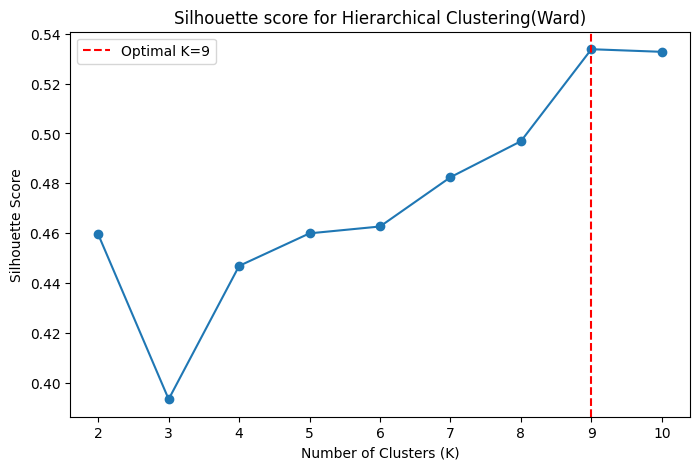

In [38]:
# Extract the distances at which clusters merge
distances = linkage_matrix[:, 2]  # Column 2 contains the distances
num_clusters = np.arange(len(distances), 0, -1)

# Limit cluster range 2 to 10
min_k = 2
max_k = 10
mask = (num_clusters >= min_k) & (num_clusters <= max_k)
filtered_clusters = num_clusters[mask]
filtered_distances = distances[mask]

hier_kneedle = KneeLocator(filtered_clusters, filtered_distances, curve="convex", direction="decreasing")

hier_elbow_k = hier_kneedle.elbow
print(f"The optimal number of clusters is: {hier_elbow_k}")

plot_elbow_ward(hier_elbow_k, filtered_clusters, filtered_distances)

hier_silhouette_scores = []

for k in K_range:
    cluster_labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(df_scaled)
    score = silhouette_score(df_scaled, cluster_labels)
    hier_silhouette_scores.append(score)
    
# Find the best K (highest silhouette score)
optimal_silhouette_k = K_range[np.argmax(hier_silhouette_scores)]
print(f"Optimal number of clusters from Silhouette Score: {optimal_silhouette_k}")
plot_silhouette_scores(optimal_silhouette_k,K_range,hier_silhouette_scores,"Silhouette score for Hierarchical Clustering(Ward)")

- Optimal K Ward

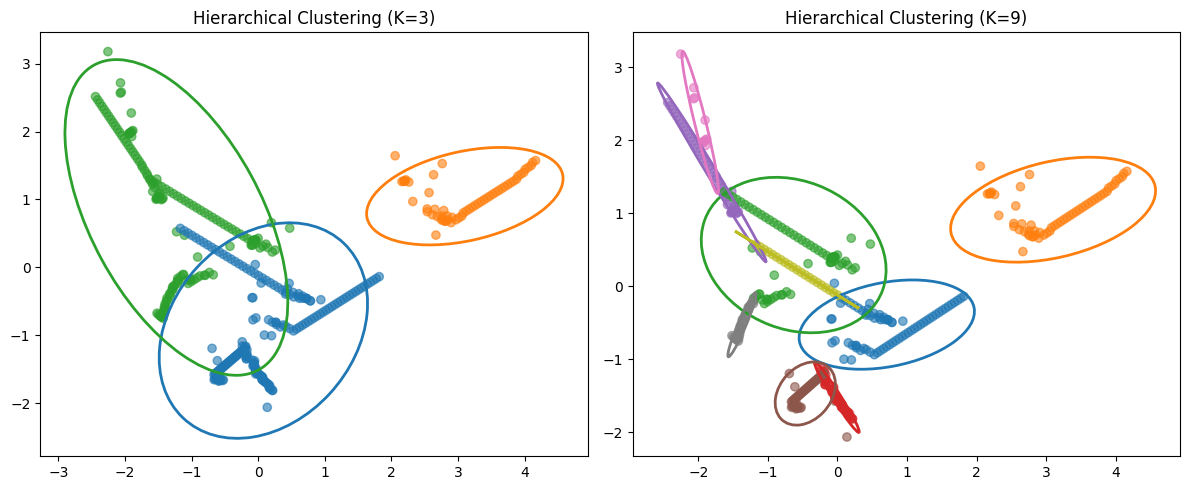

In [39]:
hierarchical_3 = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_cluster_labels_3 = hierarchical_3.fit_predict(df_scaled)

hierarchical_9 = AgglomerativeClustering(n_clusters=9, linkage='ward')
hierarchical_cluster_labels_9 = hierarchical_9.fit_predict(df_scaled)

# Scatter plot for K=3
plt.figure(figsize=(12, 5))

ax1 = plt.subplot(1, 2, 1)
unique_labels_3 = np.unique(hierarchical_cluster_labels_3)
cmap = plt.get_cmap('tab10')
color_map_3 = {label: cmap(i % 10) for i, label in enumerate(unique_labels_3)}
colors_for_scatter_3 = [color_map_3[label] for label in hierarchical_cluster_labels_3]
ax1.scatter(df_pca[:, 0], df_pca[:, 1], c=colors_for_scatter_3, alpha=0.6)
plot_confidence_ellipses(ax1, df_pca, hierarchical_cluster_labels_3, color_map_3)
ax1.set_title("Hierarchical Clustering (K=3)")

# Scatter plot for K=9
ax2 = plt.subplot(1, 2, 2)
unique_labels_9 = np.unique(hierarchical_cluster_labels_9)
color_map_9 = {label: cmap(i % 10) for i, label in enumerate(unique_labels_9)}
colors_for_scatter_9 = [color_map_9[label] for label in hierarchical_cluster_labels_9]
ax2.scatter(df_pca[:, 0], df_pca[:, 1], c=colors_for_scatter_9, alpha=0.6)
plot_confidence_ellipses(ax2, df_pca, hierarchical_cluster_labels_9, color_map_9)
ax2.set_title("Hierarchical Clustering (K=9)")

plt.tight_layout()
plt.show()



- Apply Hierarchical Agglomerative Clustering Algorithm with Ward Linkage distance metric

For k = 29 we see too many clusters some overlapping 

In [40]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(df_scaled)

- Comrare K-means and Hierarchical


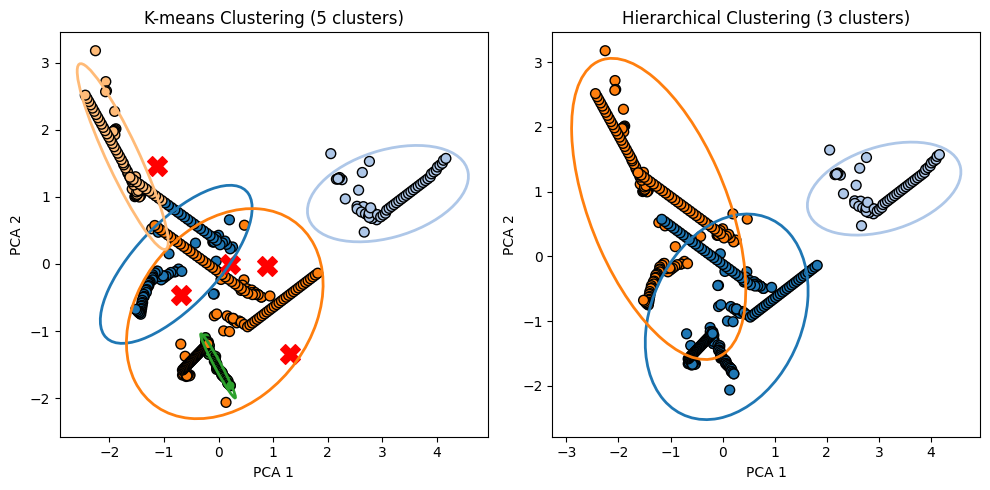

In [41]:
# Plot for K-means clusters
cmap = plt.get_cmap('tab20')
unique_kmeans = np.unique(kmeans_labels)
color_map_kmeans = {label: cmap(i % 20) for i, label in enumerate(unique_kmeans)}
kmeans_colors = [color_map_kmeans[label] for label in kmeans_labels]


plt.figure(figsize=(10, 5))

ax1 = plt.subplot(1, 2, 1)
ax1.scatter(df_pca[:, 0], df_pca[:, 1], c=kmeans_colors, edgecolor='k', s=50)
ax1.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', s=200, c='red')
plot_confidence_ellipses(ax1, df_pca, kmeans_labels, color_map_kmeans)
ax1.set_title("K-means Clustering (5 clusters)")
ax1.set_xlabel('PCA 1')
ax1.set_ylabel('PCA 2')

# Plot for Hierarchical clusters
unique_hier = np.unique(hierarchical_labels)
color_map_hier = {label: cmap(i % 20) for i, label in enumerate(unique_hier)}
hier_colors = [color_map_hier[label] for label in hierarchical_labels]

ax2 = plt.subplot(1, 2, 2)
ax2.scatter(df_pca[:, 0], df_pca[:, 1], c=hier_colors, edgecolor='k', s=50)
plot_confidence_ellipses(ax2, df_pca, hierarchical_labels, color_map_hier)
ax2.set_title("Hierarchical Clustering (3 clusters)")
ax2.set_xlabel('PCA 1')
ax2.set_ylabel('PCA 2')

plt.tight_layout()
plt.show()

- Pair Plot

In [42]:
# # Create a DataFrame with cluster labels
# df_for_plot = pd.DataFrame(df_scaled)
# df_for_plot['labels'] = kmeans_labels
# 
# # Plot pair plot with custom palette
# sns.pairplot(df_for_plot, hue='labels', palette='tab20')
# plt.show()
# 
# df_for_plot['labels'] = hierarchical_labels
# sns.pairplot(df_for_plot, hue='labels', palette='tab20')
# plt.show()


In [43]:
# Number of data points in each cluster
kmeans_counts = np.bincount(kmeans_labels)
hierarchical_counts = np.bincount(hierarchical_labels)

print(f"K-Means Cluster Sizes: {kmeans_counts}")
print(f"Hierarchical Cluster Sizes: {hierarchical_counts}")

K-Means Cluster Sizes: [ 87  57 139  71  46]
Hierarchical Cluster Sizes: [187  57 156]


- SOM

In [44]:
from minisom import MiniSom

N = df_scaled.shape[0]
som_shape = (2, 2)
som = MiniSom(2, 2, data.shape[1], sigma=1.0, learning_rate=0.3, sigma_decay_function='inverse_decay_to_one',   decay_function ='inverse_decay_to_zero',neighborhood_function='gaussian',activation_distance='euclidean' ,random_seed=10)

som.train_batch(data, 10000, verbose=False)
 # som_cluster_labels
winner_coordinates = np.array([som.winner(x) for x in data]).T
# Convert 2D coordinates into 1D
cluster_index = np.ravel_multi_index(winner_coordinates, som_shape)


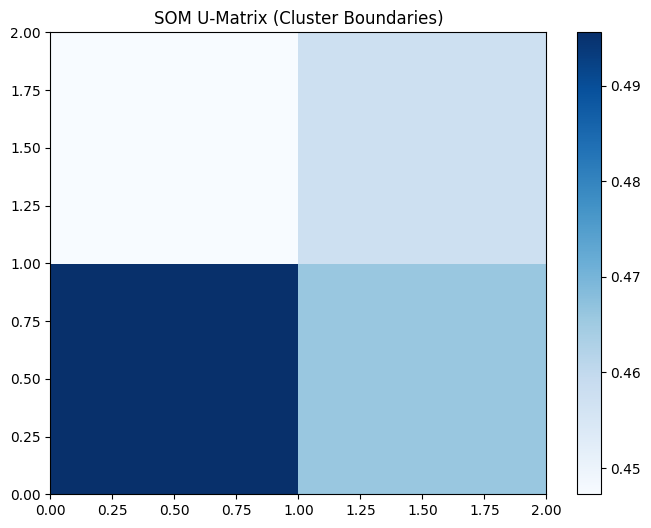

In [45]:
from pylab import plot, colorbar, pcolor

# Compute distances between neurons
u_matrix = np.zeros((som_shape[0], som_shape[1]))

for i in range(som_shape[0]):
    for j in range(som_shape[1]):
        neighbors = som.get_weights()[max(0, i-1):i+2, max(0, j-1):j+2]
        u_matrix[i, j] = np.mean(np.linalg.norm(neighbors - som.get_weights()[i, j], axis=-1))

# Plot U-Matrix
plt.figure(figsize=(8, 6))
pcolor(u_matrix, cmap='Blues')  # Choose color map
colorbar()
plt.title('SOM U-Matrix (Cluster Boundaries)')
plt.show()


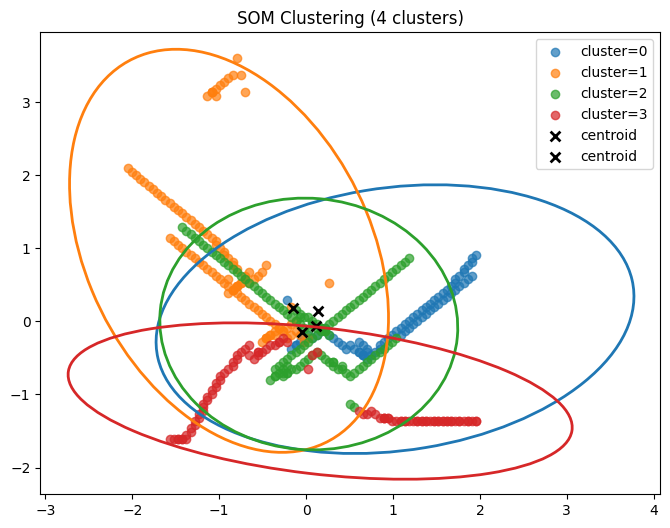

In [46]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10.colors[:4] 
color_map = {label: color for label, color in zip(np.unique(cluster_index), colors)}

for c in np.unique(cluster_index):
    ax.scatter(data[cluster_index == c, 0],
               data[cluster_index == c, 1],
               label='cluster='+str(c), alpha=.7, color=color_map[c])

for centroid in som.get_weights():
    ax.scatter(centroid[:, 0], centroid[:, 1], marker='x', 
               s=50, linewidths=2, color='k', label='centroid')

plot_confidence_ellipses(ax, data, cluster_index, color_map)

ax.set_title("SOM Clustering (4 clusters)")
ax.legend()
plt.show()

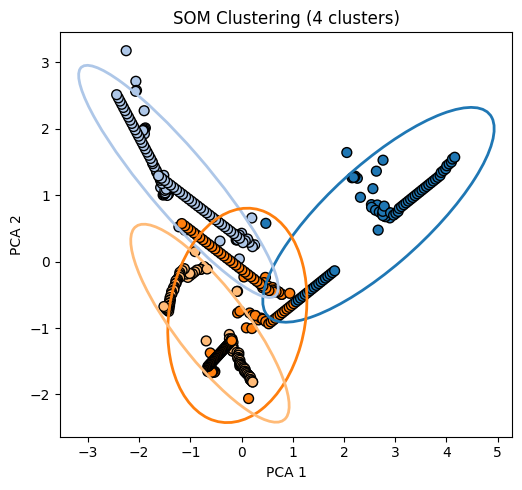

In [47]:
# Plot for K-means clusters
cmap = plt.get_cmap('tab20')

plt.figure(figsize=(10, 5))

# Plot for Hierarchical clusters
unique_SOM= np.unique(cluster_index)
color_map_SOM = {label: cmap(i % 20) for i, label in enumerate(unique_SOM)}
SOM_colors = [color_map_SOM[label] for label in cluster_index]

ax3 = plt.subplot(1, 2, 1)
ax3.scatter(df_pca[:, 0], df_pca[:, 1], c=SOM_colors, edgecolor='k', s=50)
plot_confidence_ellipses(ax3, df_pca, cluster_index, color_map_SOM)
ax3.set_title("SOM Clustering (4 clusters)")
ax3.set_xlabel('PCA 1')
ax3.set_ylabel('PCA 2')

plt.tight_layout()
plt.show()

In [48]:
df['kmeans_cluster'] = kmeans_labels
df['hierarchical_cluster'] = hierarchical_labels
df['som_cluster'] = cluster_index
df

,Timestamp,User_ID,Application_Type,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation,kmeans_cluster,hierarchical_cluster,som_cluster
0,2023-09-03 10:00:00,User_1,Video_Call,-75,30.0,10000.0,15000.0,70,1,1,0
1,2023-09-03 10:00:00,User_2,Voice_Call,-80,20.0,100.0,120.0,80,2,0,3
2,2023-09-03 10:00:00,User_3,Streaming,-85,40.0,5000.0,6000.0,75,2,2,0
3,2023-09-03 10:00:00,User_4,Emergency_Service,-70,10.0,1000.0,1500.0,90,2,0,2
4,2023-09-03 10:00:00,User_5,Online_Gaming,-78,25.0,2000.0,3000.0,85,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...
395,2023-09-03 10:06:00,User_396,Streaming,-110,61.0,1300.0,1800.0,85,2,0,2
396,2023-09-03 10:06:00,User_397,Video_Call,-40,53.0,14500.0,15800.0,75,1,1,0
397,2023-09-03 10:06:00,User_398,Video_Streaming,-113,58.0,1000.0,1400.0,70,3,2,1
398,2023-09-03 10:06:00,User_399,Emergency_Service,-40,5.0,400.0,400.0,70,4,0,3


In [49]:
# Raw counts
print(df.groupby('kmeans_cluster')['Application_Type'].value_counts())
print(df.groupby('hierarchical_cluster')['Application_Type'].value_counts())
print(df.groupby('som_cluster')['Application_Type'].value_counts())

kmeans_cluster  Application_Type   
0               Web_Browsing           48
                Video_Streaming        35
                Online_Gaming           2
                File_Download           1
                Streaming               1
1               Video_Call             57
2               Streaming              46
                VoIP_Call              46
                Online_Gaming          43
                Emergency_Service       1
                Video_Call              1
                Video_Streaming         1
                Voice_Call              1
3               Background_Download    47
                IoT_Temperature        13
                Video_Streaming        11
4               Emergency_Service      46
Name: count, dtype: int64
hierarchical_cluster  Application_Type   
0                     Emergency_Service      47
                      VoIP_Call              46
                      Online_Gaming          45
                      Streaming       

In [50]:
kmeans_app_dist = cluster_application_distribution(df, 'kmeans_cluster')
hierarchical_app_dist = cluster_application_distribution(df, 'hierarchical_cluster')
som_app_dist = cluster_application_distribution(df, 'som_cluster')

display(kmeans_app_dist)

display(hierarchical_app_dist)

display(som_app_dist)

Application_Type,Background_Download,Emergency_Service,File_Download,IoT_Temperature,Online_Gaming,Streaming,Video_Call,Video_Streaming,VoIP_Call,Voice_Call,Web_Browsing
kmeans_cluster,,,,,,,,,,,
0,0.0,0.00,1.15,0.00,2.30,1.15,0.00,40.23,0.00,0.00,55.17
1,0.0,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00,0.00
2,0.0,0.72,0.00,0.00,30.94,33.09,0.72,0.72,33.09,0.72,0.00
3,66.2,0.00,0.00,18.31,0.00,0.00,0.00,15.49,0.00,0.00,0.00
4,0.0,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


Application_Type,Background_Download,Emergency_Service,File_Download,IoT_Temperature,Online_Gaming,Streaming,Video_Call,Video_Streaming,VoIP_Call,Voice_Call,Web_Browsing
hierarchical_cluster,,,,,,,,,,,
0,0.00,25.13,0.00,0.00,24.06,24.06,0.53,1.07,24.6,0.53,0.00
1,0.00,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.0,0.00,0.00
2,30.13,0.00,0.64,8.33,0.00,1.28,0.00,28.85,0.0,0.00,30.77


Application_Type,Background_Download,Emergency_Service,File_Download,IoT_Temperature,Online_Gaming,Streaming,Video_Call,Video_Streaming,VoIP_Call,Voice_Call,Web_Browsing
som_cluster,,,,,,,,,,,
0,0.00,0.00,0.00,0.00,23.68,1.32,75.00,0.00,0.00,0.00,0.00
1,43.12,0.00,0.92,11.93,0.00,0.92,0.00,42.20,0.00,0.00,0.92
2,0.00,1.67,0.00,0.00,20.83,37.50,0.83,0.83,38.33,0.00,0.00
3,0.00,47.37,0.00,0.00,2.11,0.00,0.00,0.00,0.00,1.05,49.47


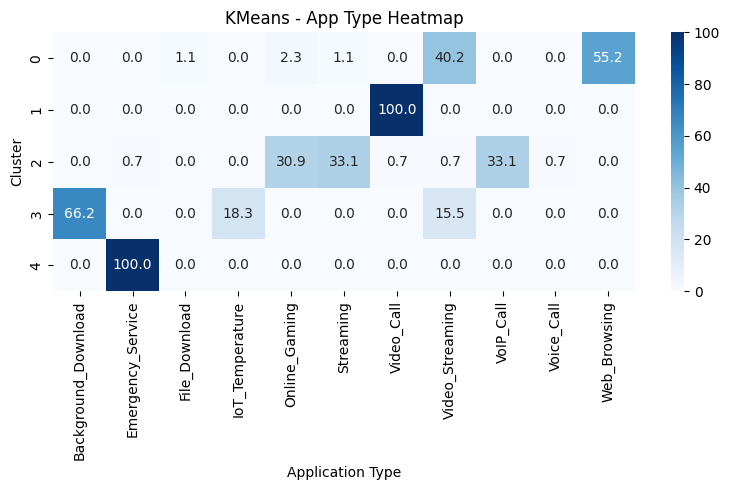

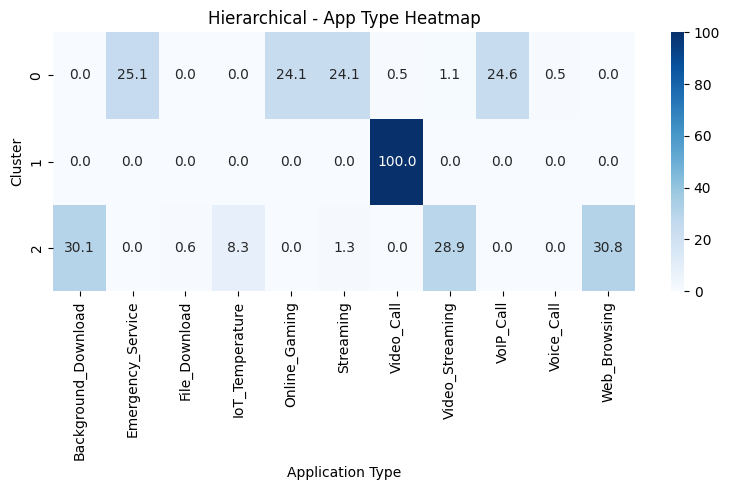

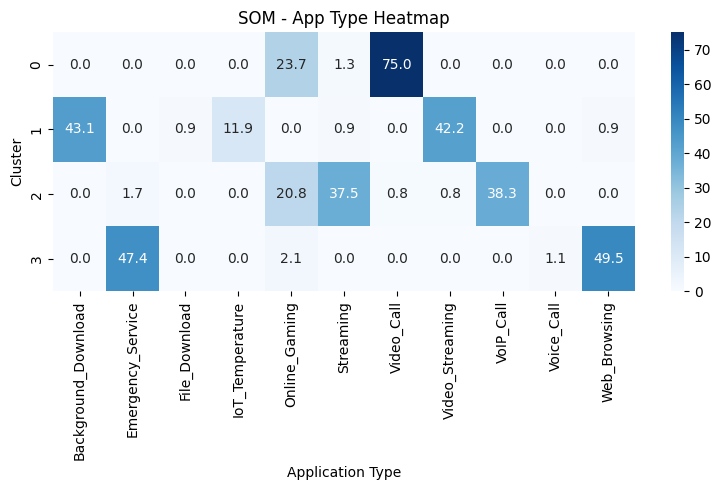

,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
Application_Type,,,,,
Background_Download,-104.06,56.98,547.87,548.94,60.11
Emergency_Service,-53.83,5.57,678.72,744.68,70.64
File_Download,-75.00,45.00,2000.00,2000.00,70.00
IoT_Temperature,-100.23,102.15,3.85,5.15,70.38
Online_Gaming,-62.16,29.11,4140.00,4455.56,80.00
Streaming,-89.62,41.85,3353.19,3893.62,84.47
Video_Call,-62.40,32.88,11814.66,13284.05,74.48
Video_Streaming,-93.94,38.85,2938.30,3314.89,70.32
VoIP_Call,-75.78,31.30,81.63,104.13,89.89


In [51]:
plot_app_heatmap(kmeans_app_dist, 'KMeans - App Type Heatmap')
plot_app_heatmap(hierarchical_app_dist, 'Hierarchical - App Type Heatmap')
plot_app_heatmap(som_app_dist, 'SOM - App Type Heatmap')

app_type_means = df.groupby('Application_Type')[numeric_vars].mean().round(2)
display(app_type_means)


- EVALUATE ALL ALGORITHMS FOR K = 4

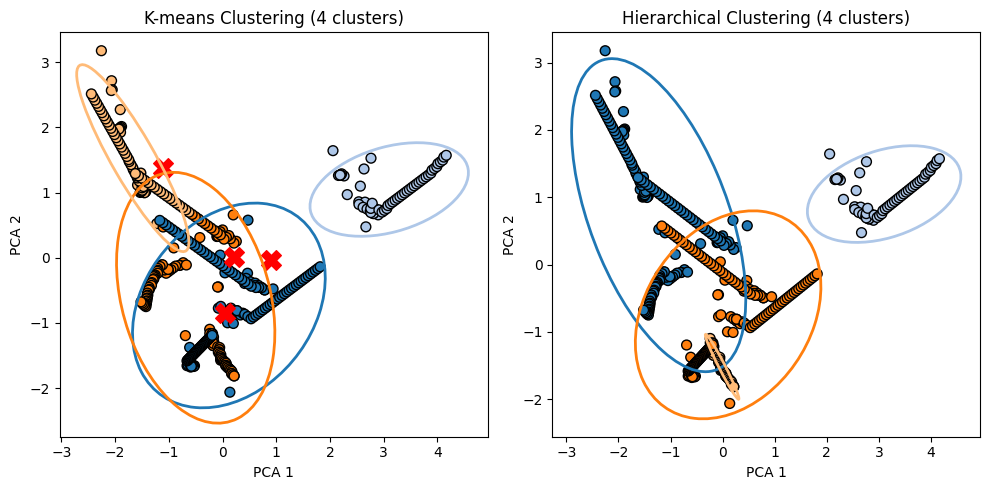

In [52]:
# Optimal number of clusters for K-means based on PCA is 
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df_scaled)

hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(df_scaled)

unique_kmeans = np.unique(kmeans_labels)
color_map_kmeans = {label: cmap(i % 20) for i, label in enumerate(unique_kmeans)}
kmeans_colors = [color_map_kmeans[label] for label in kmeans_labels]


plt.figure(figsize=(10, 5))

ax1 = plt.subplot(1, 2, 1)
ax1.scatter(df_pca[:, 0], df_pca[:, 1], c=kmeans_colors, edgecolor='k', s=50)
ax1.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', s=200, c='red')
plot_confidence_ellipses(ax1, df_pca, kmeans_labels, color_map_kmeans)
ax1.set_title("K-means Clustering (4 clusters)")
ax1.set_xlabel('PCA 1')
ax1.set_ylabel('PCA 2')

# Plot for Hierarchical clusters
unique_hier = np.unique(hierarchical_labels)
color_map_hier = {label: cmap(i % 20) for i, label in enumerate(unique_hier)}
hier_colors = [color_map_hier[label] for label in hierarchical_labels]

ax2 = plt.subplot(1, 2, 2)
ax2.scatter(df_pca[:, 0], df_pca[:, 1], c=hier_colors, edgecolor='k', s=50)
plot_confidence_ellipses(ax2, df_pca, hierarchical_labels, color_map_hier)
ax2.set_title("Hierarchical Clustering (4 clusters)")
ax2.set_xlabel('PCA 1')
ax2.set_ylabel('PCA 2')

plt.tight_layout()
plt.show()

In [53]:
# Number of data points in each cluster
kmeans_counts = np.bincount(kmeans_labels)
hierarchical_counts = np.bincount(hierarchical_labels)
som_counts = np.bincount(cluster_index)

print(f"K-Means Cluster Sizes: {kmeans_counts}")
print(f"Hierarchical Cluster Sizes: {hierarchical_counts}")
print(f"SOM Cluster Sizes: {som_counts}")

K-Means Cluster Sizes: [139  57 126  78]
Hierarchical Cluster Sizes: [156  57 142  45]
SOM Cluster Sizes: [ 76 109 120  95]
